<a href="https://colab.research.google.com/github/chanu-24/car-vision-study/blob/main/Week4_Day2_VideoTracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 1. 도로의 무법자들을 잡아낼 'YOLOv5' 소환!
requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master


WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
                                  ^^^



YOLOv5 🚀 2026-4-12 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



🎬 2. 고속도로 쌩쌩 달리는 영상으로 교체!

🎥 3. 영상 프레임 쪼개기 및 AI 실시간 분석 시작!

--- 🎞️ 1번째 캡처 (시간 훌쩍 건너뜀!) ---


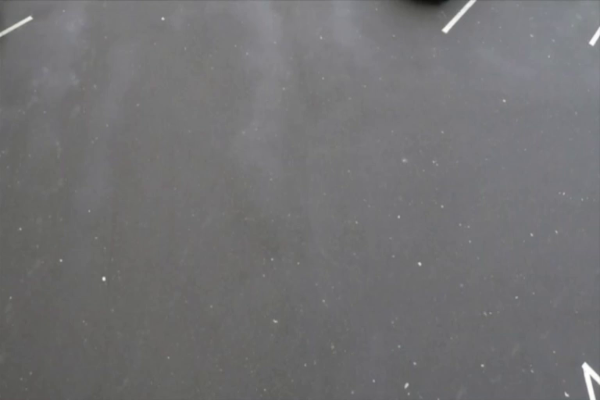

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



--- 🎞️ 2번째 캡처 (시간 훌쩍 건너뜀!) ---


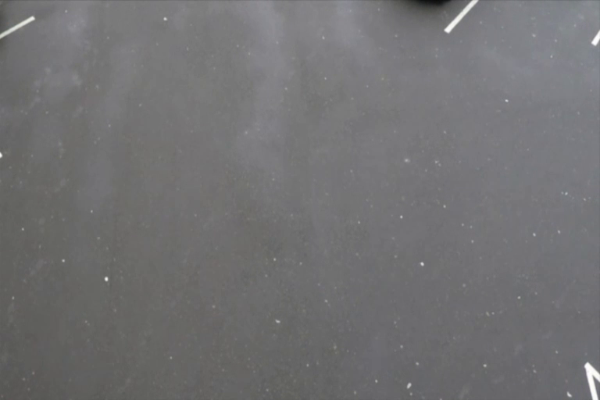

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



--- 🎞️ 3번째 캡처 (시간 훌쩍 건너뜀!) ---


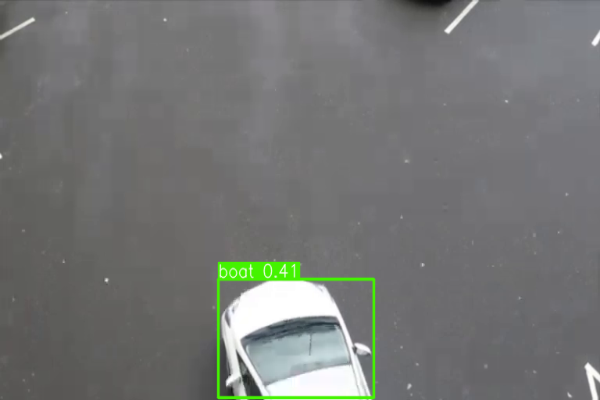

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



--- 🎞️ 4번째 캡처 (시간 훌쩍 건너뜀!) ---


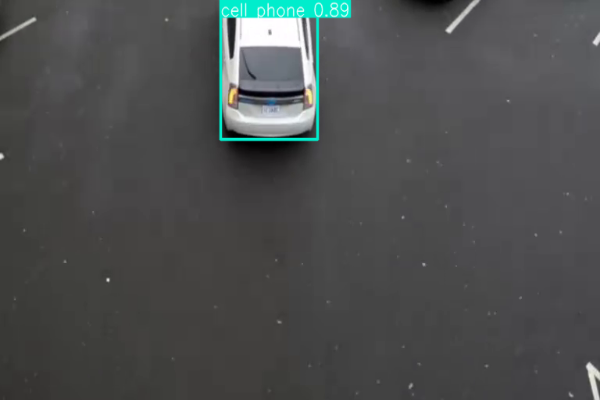

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



--- 🎞️ 5번째 캡처 (시간 훌쩍 건너뜀!) ---


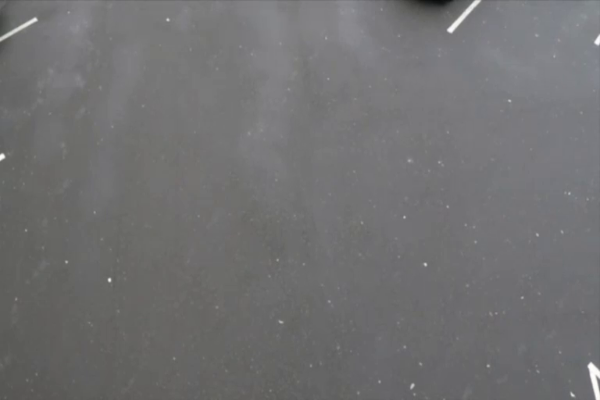


✅ 삐빅! 타임랩스 모드 검증 완료!


In [8]:
# 🛠️ 0. 코랩이 까먹은 패키지 다시 설치해주기 (약 10초 소요)
!pip install -q ultralytics

import torch
import cv2
import urllib.request
from google.colab.patches import cv2_imshow

print("🚀 1. 도로의 무법자들을 잡아낼 'YOLOv5' 소환!")
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# 기존 코드 지우고 이걸로 변경!
print("\n🎬 2. 고속도로 쌩쌩 달리는 영상으로 교체!")
video_url = "https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/car-detection.mp4"
urllib.request.urlretrieve(video_url, 'test_video.mp4')

print("\n🎥 3. 영상 프레임 쪼개기 및 AI 실시간 분석 시작!")
# cv2.VideoCapture: 영상을 가져와서 프레임(사진) 단위로 쪼개주는 마법의 함수!
cap = cv2.VideoCapture('test_video.mp4')

frame_count = 0
while cap.isOpened() and frame_count < 5: # 듬성듬성 5장만 뽑아봅시다

    success, frame = cap.read()
    if not success:
        break

    # YOLO 뇌로 분석!
    results = model(frame)

    print(f"\n--- 🎞️ {frame_count + 1}번째 캡처 (시간 훌쩍 건너뜀!) ---")
    results.render()
    display_img = cv2.resize(results.ims[0], (600, 400))
    cv2_imshow(display_img)

    # 💡 [핵심 트릭] 사진 한 장 분석했으면, 뒤에 있는 30장(약 1초 분량)은 강제로 버려!!
    current_frame = cap.get(cv2.CAP_PROP_POS_FRAMES) # 현재 위치 파악
    cap.set(cv2.CAP_PROP_POS_FRAMES, current_frame + 30) # 30칸 앞으로 강제 점프!

    frame_count += 1

cap.release()
print("\n✅ 삐빅! 타임랩스 모드 검증 완료!")

어제 우리는 사진 한장을 던져주고 그안에서 자동차와 사람을 찾아내는
**자율주행의 눈(YOLO)**을 개안했다. 하지만 실제 자동차는 도로위를 시속 100KM로 달린다. 사진 한장 덜렁 찍고 끝날 일이 아니다.

오늘은 실전도로주행:실시간 영상(video)객체 탐지

"동영상에 AI를 어떻게 적용하나요?"

정답은 엄청 허무할정도로 간단하다.

동영상은 사실 1초에 30장(30FPS)의 사진을 연속으로 보여주는것뿐

1.카메라가 영상을 찍는다.

2.영상을 사진(Frame)단위로 1장씩 쪼갠다,(While 반복문 사용)

3.쪼갠 사진을 어제 썻던 YOLO뇌에 던져준다.

4.AI가 박스를 그린 사진을 다시 합쳐서 모니터에 연속으로 보여준다.

이때 AI의 두뇌(연산속도)가 느려서 1초에 사진을 5장 밖에 처리하지못한다면 (5FPS) ,화면속 AI의 바운딩받스는 자동차를 못따라가고 버벅거리게 된다.

아래 시뮬레이터FPS(초당 처리프레임) 수치에 따라 자율주행 AI의 추적능력이 어떻게 달라지는지 직접눈으로 확인

